In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym

In [5]:
def peaks(x,y):
    x,y = np.meshgrid(x,y)
    z = 3*(1-x)**2*np.exp(-(x**2)-(y+1)**2) -10*(x/5-x**3-y**5)*np.exp(-x**2-y**2) -1/3*np.exp(-(x+1)**2-y**2)
    return z

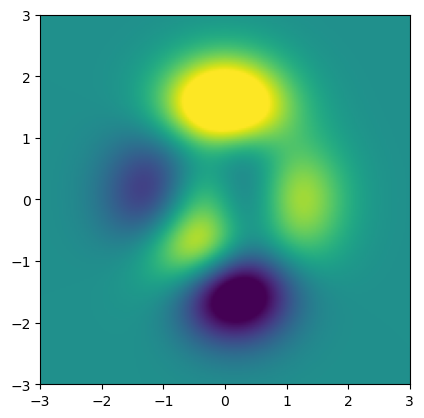

In [8]:
x = np.linspace(-3,3,201)
y = np.linspace(-3,3,201)

Z = peaks(x,y)

plt.imshow(Z,extent=[x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5,origin='lower')
plt.show()

In [9]:
sx,sy = sym.symbols('sx,sy')

sZ =  3*(1-sx)**2*sym.exp(-(sx**2)-(sy+1)**2) -10*(sx/5-sx**3-sy**5)*sym.exp(-sx**2-sy**2) -1/3*sym.exp(-(sx+1)**2-sy**2)

df_x = sym.lambdify((sx,sy),sym.diff(sZ,sx),'sympy')
df_y = sym.lambdify((sx,sy),sym.diff(sZ,sy),'sympy')

df_x(1,1).evalf()

-1.07369833656079

In [11]:
localmin = np.random.rand(2)*4-2
startpnt = localmin[:]

#Learning parameters
learning_rate = .01
training_epochs = 1000

#run through training
trajectory = np.zeros((training_epochs,2))
for i in range(training_epochs):
    grad = np.array([df_x(localmin[0],localmin[1]).evalf(),
                    df_y(localmin[0],localmin[1]).evalf()])
    localmin = localmin- learning_rate*grad
    trajectory[i,:] = localmin
print(localmin)
print(startpnt)

[0.228278920556369 -1.62553495750000]
[ 1.42250106 -1.22835938]


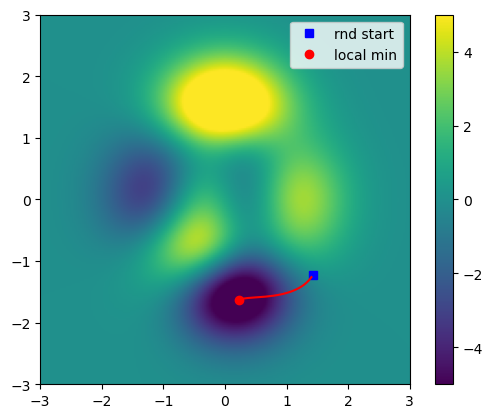

In [14]:
plt.imshow(Z,extent=[x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5,origin='lower')
plt.plot(startpnt[0],startpnt[1],'bs')
plt.plot(localmin[0],localmin[1],'ro')
plt.plot(trajectory[:,0],trajectory[:,1],'r')
plt.legend(['rnd start','local min'])
plt.colorbar()
plt.show()